## 바이오 빅데이터 분석 (2)
### 회귀 분석 실습 확장: Gene expression + mutation feature 기반 표적항암제 반응 예측

이 노트북은 기존 CCLE/CTRP 회귀 실습을 확장하여, 유전자 발현 feature에 약물 표적 유전자의 mutation feature를 추가합니다. 특히 표적항암제는 표적 단백질과 관련 pathway의 genomic alteration에 영향을 받을 수 있으므로, gene expression only 모델과 expression + mutation 모델의 차이를 관찰하는 것이 목표입니다.

**학습 목표**
- CCLE 유전자 발현과 mutation 정보를 같은 세포주 기준으로 병합한다.
- `gene_symbol_of_protein_target`에 기반해 약물별 mutation feature를 만든다.
- `mut_<gene>_any`, `mut_<gene>_damaging`, `mut_<gene>_hotspot` binary feature를 이해한다.
- 표적항암제 반응 예측에서 mutation feature 추가가 성능에 미치는 영향을 평가한다.
- 화학항암제와 표적항암제의 예측 성능 차이를 생물학적으로 해석한다.


### 0. 실행 환경

로컬 폴더에 있는 `data_CCLE_CTRPv2/*.csv` 파일을 우선 사용합니다. 로컬 CSV가 없고 Colab 등에서 실행하는 경우에는 `mlbi-lab`의 `load_data('ccle-ctrpv2')`를 사용할 수 있습니다.


In [1]:
# Colab에서 로컬 CSV가 없을 때만 실행하세요.
!pip install mlbi-lab
!pip install xgboost

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from mlbi import load_workshop_data

load_workshop_data()

# load_workshop_data('ML_CCLE_CTRPv2')

The item must be one of .. 
   BI_Files_for_GATK
   BI_Files_for_GATK_full
   BI_RNAseq_CRC_chr12
   BI_RNAseq_CRC_chr12_bam
   BI_RNAseq_pacbio_chr12
   BI_RNAseq_pacbio_chr12_bam
   BI_RNAseq_sample_chr12
   BI_RefGenome_hg38_sel
   BI_WES_PDAC_chr17
   BI_WES_PDAC_chr17_bam
   BI_WES_sample_chr17
   ML_CCLE_CTRPv2
   ML_CancerSEEK
   ML_GDSC
   ML_Genome_to_Fields
   ML_Genome_to_Fields_2024
   ML_METABRIC
   ML_QM9
   ML_TCGA_BRCA 


In [7]:
load_workshop_data('ML_CCLE_CTRPv2')

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1q2XqSycVSrgFPJ4FUI2qWHxIKqYYTdij
From (redirected): https://drive.google.com/uc?export=download&id=1q2XqSycVSrgFPJ4FUI2qWHxIKqYYTdij&confirm=t&uuid=112ec4a9-0605-41e5-bb1a-c230f2d6ad2e
To: /content/downloaded
100%|██████████| 150M/150M [00:01<00:00, 106MB/s]


Folder extracted to: data_CCLE_CTRPv2


'data_CCLE_CTRPv2'

In [8]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from sklearn import linear_model as lm
from sklearn import metrics as met
from sklearn import model_selection as mod_sel
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 5
sns.set_theme(style='whitegrid', context='notebook')


### 1. 데이터 로드

사용 데이터는 다음 6개입니다.

- `gene_expression`: 세포주 x 유전자 발현 행렬
- `auc`: 세포주 x 약물 AUC 반응 행렬
- `ec50`: 세포주 x 약물 EC50 반응 행렬
- `drug_info`: 약물 메타데이터
- `cellline_info`: 세포주 메타데이터
- `mutation_info`: 세포주별 somatic mutation long-format table


In [9]:
def load_ccle_ctrpv2(base_dir='data_CCLE_CTRPv2'):
    """Load CCLE/CTRPv2 data from local CSV files, with mlbi-lab fallback."""
    base = Path(base_dir)
    files = {
        'gene_expression': base / 'ccle_ctrpv2_gene_exp.csv',
        'cellline_info': base / 'ccle_ctrpv2_cellline_info.csv',
        'auc': base / 'ccle_ctrpv2_auc.csv',
        'ec50': base / 'ccle_ctrpv2_ec50.csv',
        'drug_info': base / 'ccle_ctrpv2_drug_info.csv',
        'mutation_info': base / 'ccle_ctrpv2_mutation_info.csv',
    }

    if all(path.exists() for path in files.values()):
        return {key: pd.read_csv(path, index_col=0) for key, path in files.items()}

    try:
        from mlbi.data import load_data
        return load_data('ccle-ctrpv2')
    except Exception as exc:
        raise FileNotFoundError(
            'Local CSV files were not found and mlbi-lab fallback failed. '
            'Check data_CCLE_CTRPv2/ or install mlbi-lab.'
        ) from exc


data = load_ccle_ctrpv2()
data.keys()

  #파일 6개 전부 있는지 확인

dict_keys(['gene_expression', 'cellline_info', 'auc', 'ec50', 'drug_info', 'mutation_info'])

In [10]:
# 각 파일 데이터프레임으로 만들고 사이즈 확인

df_gexp = data['gene_expression']
df_cl_info = data['cellline_info']
df_auc = data['auc']
df_ec50 = data['ec50']
df_drug_info = data['drug_info']
df_mutation_info = data['mutation_info']

print('gene expression:', df_gexp.shape)
print('cell line info :', df_cl_info.shape)
print('AUC            :', df_auc.shape)
print('EC50           :', df_ec50.shape)
print('drug info      :', df_drug_info.shape)
print('mutation info  :', df_mutation_info.shape)

  # gene expression, cell line info, AUC, EC50 은 cell line에 대해 동일하게 매칭
  # drug info, AUC, EC50은 drug에 대해 동일하게 매칭
  # mutation info는 gene expression 중에 mutation만 정리된것이라 별개의 파일인 것을 확인할 수 있음

gene expression: (826, 19177)
cell line info : (826, 27)
AUC            : (826, 545)
EC50           : (826, 545)
drug info      : (545, 11)
mutation info  : (1269999, 33)


#### Data source

Depmap portal:  https://depmap.org/portal/

    1. Cell line Gene expression (matrix)
    2. Cell line information
    3. Mutation information
    4. Copy numver variation

Cancer Therapeutic Response Portal: https://portals.broadinstitute.org/ctrp/

    5. Drug response for CCLE cell lines (EC50, AUC)
    
참고: 약물반응지표: EC50과 AUC https://royalsocietypublishing.org/doi/10.1098/rstb.2018.0226

In [11]:
df_drug_info

,master_cpd_id,cpd_name,broad_cpd_id,top_test_conc_umol,cpd_status,inclusion_rationale,gene_symbol_of_protein_target,target_or_activity_of_compound,source_name,source_catalog_id,cpd_smiles
cpd_id,,,,,,,,,,,
16-BETA-BROMOANDROSTERONE,411726,16-BETA-BROMOANDROSTERONE,BRD-K98404142,37.0,probe,pilot-set,NaN,dehydroepiandrosterone (DHEA) analog,Sigma-Aldrich,B9392,C[C@]12CC[C@H]3[C@@H](CC[C@H]4C[C@H](O)CC[C@]3...
"1S,3R-RSL-3",609060,"1S,3R-RSL-3",BRD-K23853216,33.0,probe,pilot-set,GPX4,synthetic lethal with HRAS in engineered cells...,Columbia University,NaN,COC(=O)[C@H]1Cc2c([nH]c3ccccc23)[C@@H](N1C(=O)...
3-CL-AHPC,660796,3-CL-AHPC,BRD-A09890259,66.0,probe,outreach,NR0B2,binder of nuclear receptor SHP,Sanford-Burnham Medical Research Institute,NaN,OC(=O)\C=C\c1ccc(c(Cl)c1)-c1ccc(O)c(c1)C12C[C@...
968,660080,968,BRD-A43210826,66.0,probe,lit-search,GLS,inhibitor of glutaminase,Specs,AG-690/36107028,CN(C)c1ccc(cc1Br)C1Nc2ccc3ccccc3c2C2=C1C(=O)CC...
A-804598,661033,A-804598,BRD-K76894955,66.0,probe,lit-search,P2RX7,inhibitor of purinergic receptor P2X,Tocris Bioscience,4473,C[C@H](\N=C(\NC#N)Nc1cccc2ncccc12)c1ccccc1
...,...,...,...,...,...,...,...,...,...,...,...
YK 4-279,632103,YK 4-279,BRD-A62182663,33.0,probe,chromatin;pilot-set,DHX9;ERG;ETV1,inhibitor of RNA helicase A (RHA) binding to E...,Tocris Bioscience,4067,COc1ccc(cc1)C(=O)CC1(O)C(=O)Nc2c1c(Cl)ccc2Cl
YL54,651298,YL54,BRD-K58306044,66.0,probe,outreach,NaN,stapled helical peptide,Harvard University,NaN,CC[C@H](C)[C@H](NC(=O)[C@H](CCCNC(N)=N)NC(=O)[...
YM-155,417979,YM-155,BRD-K76703230,1.0,clinical,pilot-set,BIRC5,inhibitor of survivin expression,Active Biochem,A-1061,COCCn1c2c(C(=O)c3ccccc3C2=O)[n+](Cc2cnccn2)c1C


In [52]:
display(df_mutation_info.head())
print('Unique mutated cell lines:', df_mutation_info['ccl_name'].nunique())
print('Unique mutated genes     :', df_mutation_info['Hugo_Symbol'].nunique())


,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC,ccl_name
0,VPS13D,55187,37,1,12359347,12359347,+,Nonsense_Mutation,SNP,C,...,0.0,NaN,damaging,34:213,NaN,NaN,NaN,34:221,NaN,NIHOVCAR3
1,AADACL4,343066,37,1,12726308,12726322,+,In_Frame_Del,DEL,CTGGCGTGACGCCAT,...,3.0,NaN,other non-conserving,57:141,NaN,NaN,NaN,9:0,28:32,NIHOVCAR3
2,IFNLR1,163702,37,1,24484172,24484172,+,Silent,SNP,G,...,0.0,NaN,silent,118:0,NaN,NaN,10:0,118:0,18:0,NIHOVCAR3
3,TMEM57,55219,37,1,25785018,25785019,+,Frame_Shift_Ins,INS,-,...,0.0,NaN,damaging,NaN,NaN,NaN,6:28,NaN,NaN,NIHOVCAR3
4,ZSCAN20,7579,37,1,33954141,33954141,+,Missense_Mutation,SNP,T,...,0.0,NaN,other non-conserving,28:62,NaN,NaN,NaN,27:61,NaN,NIHOVCAR3
5,POU3F1,5453,37,1,38512139,38512139,+,Missense_Mutation,SNP,C,...,0.0,NaN,other non-conserving,NaN,NaN,NaN,NaN,NaN,10:4,NIHOVCAR3
6,MAST2,23139,37,1,46498028,46498028,+,Silent,SNP,C,...,0.0,0.000008,silent,NaN,33:70,NaN,23:63,NaN,8:22,NIHOVCAR3
7,GBP4,115361,37,1,89657103,89657103,+,Silent,SNP,G,...,0.0,0.000016,silent,96:0,NaN,NaN,NaN,97:0,27:15,NIHOVCAR3
8,VAV3,10451,37,1,108247170,108247170,+,Splice_Site,SNP,A,...,0.0,NaN,damaging,11:30,NaN,NaN,NaN,11:32,15:18,NIHOVCAR3
9,NBPF20,100288142,37,1,148346689,148346689,+,Missense_Mutation,SNP,T,...,0.0,0.000017,other non-conserving,NaN,NaN,NaN,6:34,257:206,21:42,NIHOVCAR3


Unique mutated cell lines: 1750
Unique mutated genes     : 18787


In [53]:
df_mutation_info.columns.values

array(['Hugo_Symbol', 'Entrez_Gene_Id', 'NCBI_Build', 'Chromosome',
       'Start_position', 'End_position', 'Strand',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'dbSNP_RS', 'dbSNP_Val_Status',
       'Genome_Change', 'Annotation_Transcript', 'DepMap_ID',
       'cDNA_Change', 'Codon_Change', 'Protein_Change', 'isDeleterious',
       'isTCGAhotspot', 'TCGAhsCnt', 'isCOSMIChotspot', 'COSMIChsCnt',
       'ExAC_AF', 'Variant_annotation', 'CGA_WES_AC', 'HC_AC', 'RD_AC',
       'RNAseq_AC', 'SangerWES_AC', 'WGS_AC', 'ccl_name'], dtype=object)

In [54]:
df_mutation_info['Variant_Classification'].value_counts()

,count
Variant_Classification,
Missense_Mutation,703284
Silent,396199
Splice_Site,43310
Frame_Shift_Del,42583
Nonsense_Mutation,40217
Frame_Shift_Ins,25411
In_Frame_Del,7939
De_novo_Start_OutOfFrame,4295
In_Frame_Ins,3341


In [56]:
df_mutation_info[['Hugo_Symbol','Variant_Type','Codon_Change','Protein_Change','Variant_Classification']]

,Hugo_Symbol,Variant_Type,Codon_Change,Protein_Change,Variant_Classification
0,VPS13D,SNP,c.(6121-6123)tCa>tAa,p.S2041*,Nonsense_Mutation
1,AADACL4,DEL,c.(784-801)tcctggcgtgacgccatc>tcc,p.WRDAI263del,In_Frame_Del
2,IFNLR1,SNP,c.(1009-1011)ggC>ggT,p.G337G,Silent
3,TMEM57,INS,c.(790-792)aaafs,p.K264fs,Frame_Shift_Ins
4,ZSCAN20,SNP,c.(493-495)gTg>gGg,p.V165G,Missense_Mutation
...,...,...,...,...,...
1269994,EHBP1L1,DEL,c.(2455-2457)ttgfs,p.L819fs,Frame_Shift_Del
1269995,SACS,DEL,c.(13432-13434)tacfs,p.Y4478fs,Frame_Shift_Del
1269996,CBFB,INS,c.(262-264)ttafs,p.L88fs,Frame_Shift_Ins
1269997,TAF15,DEL,c.(1408-1431)ggctatggaggagaccgaggaggtdel,p.GYGGDRGG478del,In_Frame_Del


In [57]:
df_mutation_info['Variant_Type'].value_counts()

,count
Variant_Type,
SNP,1184790
DEL,53884
INS,30695
DNP,628
TNP,2


### 2. 데이터 탐색

먼저 세포주 계통(lineage), 약물 표적, 결측값을 확인합니다. 이후 실습에서는 화학항암제와 표적항암제를 나누어 성능을 비교하므로, 두 약물군의 후보 목록과 샘플 수를 함께 살펴봅니다.


In [13]:
display(df_gexp.iloc[:5, :8])
display(df_auc.iloc[:5, :8])
display(df_drug_info.head())


,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS
cell_line_name,,,,,,,,
22RV1,1.722466,3.200065,2.000000,0.150560,0.000000,0.238787,0.000000,6.567728
2313287,0.189034,2.160275,0.014355,0.111031,0.000000,1.541019,0.000000,5.514122
253J,1.028569,0.084064,0.042644,0.014355,0.000000,3.529821,0.286881,6.190812
253JBV,0.505891,0.042644,0.238787,0.070389,0.000000,4.261531,0.238787,6.151575
42MGBA,5.651339,0.042644,0.163499,0.000000,0.111031,1.000000,0.084064,5.784504


,16-BETA-BROMOANDROSTERONE,"1S,3R-RSL-3",3-CL-AHPC,968,A-804598,AA-COCF3,ABIRATERONE,ABT-199
cell_line_name,,,,,,,,
22RV1,14.565,9.2997,10.2590,14.376,NaN,12.0430,NaN,NaN
2313287,12.668,10.2310,10.4180,15.110,NaN,9.3923,NaN,NaN
253J,14.839,7.5951,11.0770,NaN,NaN,12.8750,NaN,NaN
253JBV,14.586,15.0000,10.3790,13.360,NaN,12.8060,NaN,NaN
42MGBA,14.917,6.2174,8.9201,NaN,14.147,14.5430,NaN,15.172


,master_cpd_id,cpd_name,broad_cpd_id,top_test_conc_umol,cpd_status,inclusion_rationale,gene_symbol_of_protein_target,target_or_activity_of_compound,source_name,source_catalog_id,cpd_smiles
cpd_id,,,,,,,,,,,
16-BETA-BROMOANDROSTERONE,411726,16-BETA-BROMOANDROSTERONE,BRD-K98404142,37.0,probe,pilot-set,NaN,dehydroepiandrosterone (DHEA) analog,Sigma-Aldrich,B9392,C[C@]12CC[C@H]3[C@@H](CC[C@H]4C[C@H](O)CC[C@]3...
"1S,3R-RSL-3",609060,"1S,3R-RSL-3",BRD-K23853216,33.0,probe,pilot-set,GPX4,synthetic lethal with HRAS in engineered cells...,Columbia University,NaN,COC(=O)[C@H]1Cc2c([nH]c3ccccc23)[C@@H](N1C(=O)...
3-CL-AHPC,660796,3-CL-AHPC,BRD-A09890259,66.0,probe,outreach,NR0B2,binder of nuclear receptor SHP,Sanford-Burnham Medical Research Institute,NaN,OC(=O)\C=C\c1ccc(c(Cl)c1)-c1ccc(O)c(c1)C12C[C@...
968,660080,968,BRD-A43210826,66.0,probe,lit-search,GLS,inhibitor of glutaminase,Specs,AG-690/36107028,CN(C)c1ccc(cc1Br)C1Nc2ccc3ccccc3c2C2=C1C(=O)CC...
A-804598,661033,A-804598,BRD-K76894955,66.0,probe,lit-search,P2RX7,inhibitor of purinergic receptor P2X,Tocris Bioscience,4473,C[C@H](\N=C(\NC#N)Nc1cccc2ncccc12)c1ccccc1


In [14]:
print('Gene expression missing values:', int(df_gexp.isnull().sum().sum()))
print('AUC missing values            :', int(df_auc.isnull().sum().sum()))
print('EC50 missing values           :', int(df_ec50.isnull().sum().sum()))


Gene expression missing values: 0
AUC missing values            : 90417
EC50 missing values           : 90417


In [15]:
if 'lineage' in df_cl_info.columns:
    display(df_cl_info['lineage'].value_counts().head(15))

if 'gene_symbol_of_protein_target' in df_drug_info.columns:
    display(df_drug_info['gene_symbol_of_protein_target'].value_counts().head(15))


,count
lineage,
lung,154
blood,71
lymphocyte,54
colorectal,48
central_nervous_system,47
skin,46
breast,40
pancreas,38
ovary,38


,count
gene_symbol_of_protein_target,
HDAC1;HDAC2;HDAC3;HDAC6;HDAC8,9
MTOR,5
DNMT1,5
EGFR;ERBB2,5
RARA;RARB;RARG,4
BCL2;BCL2L1;BCL2L2,4
BRAF,4
NAMPT,4
HDAC1;HDAC2,4


In [16]:
df_cl_info.columns

Index(['cell_line_name.1', 'CCLE_Name', 'alias', 'COSMICID', 'sex', 'source',
       'Achilles_n_replicates', 'cell_line_NNMD', 'culture_type',
       'culture_medium', 'cas9_activity', 'RRID', 'WTSI_Master_Cell_ID',
       'sample_collection_site', 'primary_or_metastasis', 'primary_disease',
       'Subtype', 'age', 'Sanger_Model_ID', 'depmap_public_comments',
       'lineage', 'lineage_subtype', 'lineage_sub_subtype',
       'lineage_molecular_subtype', 'cell_line_name_og', 'depmap_id',
       'stripped_cell_line_name'],
      dtype='object')

#### 몇가지 표적항암제 확인

In [17]:
tinib_mask = df_drug_info['cpd_name'].astype(str).str.endswith('TINIB', na=False)
tinib_drugs = df_drug_info.loc[tinib_mask].index.intersection(df_auc.columns).tolist()
print(f'Number of TINIB drugs in AUC matrix: {len(tinib_drugs)}')
display(tinib_drugs[:20])

  #tinib으로 끝나는 것은 표적항암제 (Target Inhibitor)

Number of TINIB drugs in AUC matrix: 28


['AFATINIB',
 'AXITINIB',
 'BOSUTINIB',
 'CABOZANTINIB',
 'CANERTINIB',
 'CRIZOTINIB',
 'DASATINIB',
 'ERLOTINIB',
 'FORETINIB',
 'GEFITINIB',
 'IBRUTINIB',
 'IMATINIB',
 'LAPATINIB',
 'LENVATINIB',
 'LINSITINIB',
 'MASITINIB',
 'MOMELOTINIB',
 'NERATINIB',
 'NILOTINIB',
 'QUIZARTINIB']

#### 화학항암제 후보 확인

아래 약물들은 DNA damage, topoisomerase, microtubule, platinum 계열 등 전통적인 화학항암제에 가까운 후보입니다. 이 데이터에서는 이런 약물들이 유전자 발현 기반 회귀 예측에서 비교적 좋은 성능을 보이는 경우가 많아서, 이후 실습의 기본 타깃으로 사용합니다.


In [18]:
chemo_drug_candidates = [
    'CLOFARABINE',
    'CYTARABINE HYDROCHLORIDE',
    'DECITABINE',
    'PACLITAXEL',
    'DOCETAXEL',
    'DOXORUBICIN',
    'GEMCITABINE',
    'TOPOTECAN',
    'ETOPOSIDE',
    'TENIPOSIDE',
    'CARBOPLATIN',
    'OXALIPLATIN',
    'VINCRISTINE',
]
chemo_drug_candidates = [drug for drug in chemo_drug_candidates if drug in df_auc.columns]

chemo_summary = df_drug_info.reindex(chemo_drug_candidates)[[
    'cpd_name',
    'target_or_activity_of_compound',
    'gene_symbol_of_protein_target',
    'inclusion_rationale',
]].copy()
chemo_summary['n_AUC_samples'] = df_auc[chemo_drug_candidates].notna().sum()
chemo_summary = chemo_summary.sort_values('n_AUC_samples', ascending=False)
chemo_summary


,cpd_name,target_or_activity_of_compound,gene_symbol_of_protein_target,inclusion_rationale,n_AUC_samples
cpd_id,,,,,
VINCRISTINE,VINCRISTINE,inhibitor of mictrotubule assembly,NaN,std-of-care,808
DOXORUBICIN,DOXORUBICIN,inhibitor of topoisomerase II,TOP2A,std-of-care,800
TOPOTECAN,TOPOTECAN,inhibitor of topoisomerase I,TOP1,std-of-care,794
CLOFARABINE,CLOFARABINE,inducer of DNA damage,NaN,std-of-care,794
DECITABINE,DECITABINE,inhibitor of DNA methyltransferase,DNMT1,chromatin;CTEP;std-of-care,789
CARBOPLATIN,CARBOPLATIN,inducer of DNA damage,NaN,std-of-care,783
ETOPOSIDE,ETOPOSIDE,inhibitor of topoisomerase II,TOP2A,pilot-set;std-of-care,780
CYTARABINE HYDROCHLORIDE,CYTARABINE HYDROCHLORIDE,inducer of DNA damage,NaN,std-of-care,778
OXALIPLATIN,OXALIPLATIN,DNA alkylator; organoplatinum reagent,NaN,std-of-care,774


#### 표적항암제 후보 요약

비교용으로 `TINIB` 계열 표적항암제 몇 가지도 함께 정리합니다. 이후 실습에서 화학항암제 후보와 표적항암제 후보의 예측 성능을 비교해보면, 약물 작용기전과 반응 예측 난이도의 차이를 관찰할 수 있습니다.


In [19]:
targeted_drug_candidates = [
    'AFATINIB',
    'AXITINIB',
    'BOSUTINIB',
    'CABOZANTINIB',
    'CRIZOTINIB',
    'DASATINIB',
    'ERLOTINIB',
    'GEFITINIB',
    'LAPATINIB',
    'NERATINIB',
    'SUNITINIB',
]
targeted_drug_candidates = [drug for drug in targeted_drug_candidates if drug in df_auc.columns]

targeted_summary = df_drug_info.reindex(targeted_drug_candidates)[[
    'cpd_name',
    'gene_symbol_of_protein_target',
    'target_or_activity_of_compound',
    'inclusion_rationale',
]].copy()
targeted_summary['n_AUC_samples'] = df_auc[targeted_drug_candidates].notna().sum()
targeted_summary = targeted_summary.sort_values('n_AUC_samples', ascending=False)
targeted_summary


,cpd_name,gene_symbol_of_protein_target,target_or_activity_of_compound,inclusion_rationale,n_AUC_samples
cpd_id,,,,,
NERATINIB,NERATINIB,EGFR;ERBB2,inhibitor of EGFR and HER2,kinome;pilot-set,791
DASATINIB,DASATINIB,EPHA2;KIT;LCK;SRC;YES1,"inhibitor of SRC, YES1, EPHA2, c-KIT, and LCK",CTEP;kinome;std-of-care,786
AXITINIB,AXITINIB,FLT1;FLT3;KDR;KIT;PDGFRA;PDGFRB,"inhibitor of VEGFRs, c-KIT, and PDGFR alpha an...",kinome,778
ERLOTINIB,ERLOTINIB,EGFR;ERBB2,inhibitor of EGFR and HER2,CTEP;kinome;std-of-care,778
SUNITINIB,SUNITINIB,FLT1;FLT3;KDR;KIT;PDGFRA;PDGFRB,"inhibitor of VEGFRs, c-KIT, and PDGFR alpha an...",CTEP;kinome,773
CRIZOTINIB,CRIZOTINIB,ALK;MET,inhibitor of c-MET and ALK,kinome;std-of-care,769
BOSUTINIB,BOSUTINIB,ABL1;SRC,inhibitor of SRC and ABL1,kinome,766
GEFITINIB,GEFITINIB,AKT1;EGFR,inhibitor of EGFR and AKT1,chromatin;CTEP;kinome;std-of-care,759
CABOZANTINIB,CABOZANTINIB,FLT3;KDR;MET;RET,"inhibitor of c-MET, VEGFR2/3, and RET",CTEP;kinome,755


### 3. 전처리

유전자 발현값은 오른쪽으로 긴 분포를 갖는 경우가 많으므로 `log10(x + 1)` 변환을 적용합니다. 실습 속도를 위해 기본값은 분산이 큰 유전자 3,000개만 사용합니다. 전체 유전자를 사용하려면 다음 코드 셀에서 `TOP_N_GENES = None`으로 바꾸면 됩니다.


Features used for modeling: 3000


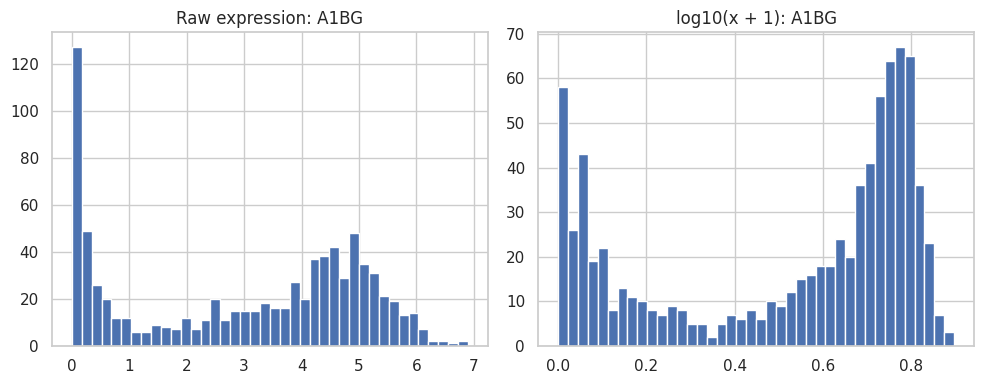

In [20]:
df_log_gexp = np.log10(df_gexp + 1)

# 전체 유전자를 모두 쓰면 일부 실습 환경에서 시간이 오래 걸릴 수 있습니다.
# 분산이 큰 유전자만 선택해 빠른 실습용 feature matrix를 만듭니다.
# 더 정밀한 분석을 원하면 TOP_N_GENES = None 으로 바꾸세요.
TOP_N_GENES = 3000
if TOP_N_GENES is None or TOP_N_GENES >= df_log_gexp.shape[1]:
    df_feature = df_log_gexp.copy()
else:
    top_genes = df_log_gexp.var(axis=0).sort_values(ascending=False).head(TOP_N_GENES).index
    df_feature = df_log_gexp.loc[:, top_genes].copy()

print('Features used for modeling:', df_feature.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_gexp.iloc[:, 0].hist(bins=40, ax=axes[0])
axes[0].set_title(f'Raw expression: {df_gexp.columns[0]}')
df_log_gexp.iloc[:, 0].hist(bins=40, ax=axes[1])
axes[1].set_title(f'log10(x + 1): {df_gexp.columns[0]}')
plt.tight_layout()


### 4. 단일 약물 AUC 회귀 문제 만들기

`target`을 바꾸면 다른 항암제에 대해 같은 분석을 반복할 수 있습니다. 이 확장 노트북에서는 mutation feature의 효과를 보기 위해 기본값을 표적항암제(`ERLOTINIB`)로 둡니다.

기본 expression feature는 `TOP_N_GENES`로 선택한 유전자에 더해, AUC matrix에 포함된 모든 compound의 valid protein target gene을 항상 포함합니다. 이어지는 셀에서 현재 약물의 protein target gene에 대한 mutation feature를 `X_df`에 추가합니다.


In [58]:
df_drug_info.loc['ERLOTINIB']

    # 'ERLOTINIB'의 target이 EGFR, ERBB2 인 것을 확인

,ERLOTINIB
master_cpd_id,52928
cpd_name,ERLOTINIB
broad_cpd_id,BRD-K70401845
top_test_conc_umol,66.0
cpd_status,FDA
inclusion_rationale,CTEP;kinome;std-of-care
gene_symbol_of_protein_target,EGFR;ERBB2
target_or_activity_of_compound,inhibitor of EGFR and HER2
source_name,Selleck
source_catalog_id,S1023


In [21]:
target = 'ERLOTINIB'

  # target만 바꾸면 바로 확인 할 수 있도록 코드 짜져 있음

response_table = df_auc

if target not in response_table.columns:
    raise ValueError(f'{target} is not available. Try one of: {list(response_table.columns[:10])}')


def parse_target_genes(drug_name, drug_info=df_drug_info):
    if drug_name not in drug_info.index or 'gene_symbol_of_protein_target' not in drug_info.columns:
        return []



    genes = drug_info.loc[drug_name, 'gene_symbol_of_protein_target']
    if pd.isna(genes):
        return []

    return [gene.strip() for gene in str(genes).split(';') if gene.strip()]


def get_all_valid_target_genes(drug_info=df_drug_info, response_table=df_auc, expression_table=df_log_gexp):
    valid_drugs = drug_info.index.intersection(response_table.columns)
    target_values = drug_info.loc[valid_drugs, 'gene_symbol_of_protein_target'].dropna()

    target_genes = []
    for genes in target_values:
        target_genes.extend([gene.strip() for gene in str(genes).split(';') if gene.strip()])

    unique_target_genes = sorted(set(target_genes))
    return [gene for gene in unique_target_genes if gene in expression_table.columns]


y_raw = response_table[target]
valid_mask = y_raw.notna() & np.isfinite(y_raw)

current_target_genes = parse_target_genes(target)
all_valid_target_genes = get_all_valid_target_genes()
target_genes_to_add = [gene for gene in all_valid_target_genes if gene not in df_feature.columns]

df_expression_feature = pd.concat(
    [
        df_feature,
        df_log_gexp.loc[:, target_genes_to_add],
    ],
    axis=1,
).copy()

X_df = df_expression_feature.loc[valid_mask].copy()
y = y_raw.loc[valid_mask].astype(float).copy()
info_sel = df_cl_info.reindex(X_df.index)

print('Target drug:', target)
print('Current drug target genes:', current_target_genes if current_target_genes else 'Not available')
print('All valid target genes in expression:', len(all_valid_target_genes))
print('Target genes added to X_df:', len(target_genes_to_add))
print('Current target genes in X_df:', [gene for gene in current_target_genes if gene in X_df.columns])
print('Samples    :', X_df.shape[0])
print('Expression features:', X_df.shape[1])
print('y range    :', (float(y.min()), float(y.max())))

  # ERLOTINIB에 대한 target gene은 EGFR, ERBB2 / 샘플은 778개, feature는 3268개 인 것을 확인

Target drug: ERLOTINIB
Current drug target genes: ['EGFR', 'ERBB2']
All valid target genes in expression: 322
Target genes added to X_df: 268
Current target genes in X_df: ['EGFR', 'ERBB2']
Samples    : 778
Expression features: 3268
y range    : (2.8088, 19.163)


#### Mutation feature 추가

현재 선택한 약물의 protein target gene에 대해 mutation feature를 만듭니다. 각 유전자마다 다음 3가지 binary feature를 생성합니다.

- `mut_<gene>_any`: 해당 유전자에 mutation이 하나라도 있으면 1
- `mut_<gene>_damaging`: `isDeleterious == True`인 mutation이 있으면 1
- `mut_<gene>_hotspot`: `isTCGAhotspot` 또는 `isCOSMIChotspot`이 True인 mutation이 있으면 1

이 feature들은 세포주 이름(`ccl_name`)을 기준으로 `X_df`에 병합됩니다.


In [59]:
df_mutation_info.columns.values
  # isTCGAhotspot에서 있는 것이면 TCGA 등록되어 있고, 실제 환자에서 WGS 돌렸을 때의 정보가 있음 >> 굉장히 중요한 정보가 될 수 있다.
  # 3가지 경우(gene에 mutation있는 경우, gene에 심각한 damage있는 경우, 실제 환자에 대한 데이터가 있는 경우)를 각각 1로 처리해서 feature만듦 (총 3개의 binary feature)
  # 각 EGFR, ERBB2에 대해 각 binary feature가 몇개 있는지 확인할 것이다.

array(['Hugo_Symbol', 'Entrez_Gene_Id', 'NCBI_Build', 'Chromosome',
       'Start_position', 'End_position', 'Strand',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'dbSNP_RS', 'dbSNP_Val_Status',
       'Genome_Change', 'Annotation_Transcript', 'DepMap_ID',
       'cDNA_Change', 'Codon_Change', 'Protein_Change', 'isDeleterious',
       'isTCGAhotspot', 'TCGAhsCnt', 'isCOSMIChotspot', 'COSMIChsCnt',
       'ExAC_AF', 'Variant_annotation', 'CGA_WES_AC', 'HC_AC', 'RD_AC',
       'RNAseq_AC', 'SangerWES_AC', 'WGS_AC', 'ccl_name'], dtype=object)

In [63]:
print(df_mutation_info['ccl_name'].unique())
  # 'ccl_name'에 어떤 값이 있는지 확인해봄 (그냥)

['NIHOVCAR3' 'HL60' 'CACO2' ... 'MUGCHOR1' 'UMCHOR1' 'JHC7']


In [64]:
# df_mutation_info에서 isTCGAhotspot와 isDeleterious가 어떤 범주를 갖는지 코드를 짜줘

print("isTCGAhotspot value counts:")
display(df_mutation_info['isTCGAhotspot'].value_counts())

print("\nisDeleterious value counts:")
display(df_mutation_info['isDeleterious'].value_counts())

isTCGAhotspot value counts:


,count
isTCGAhotspot,
False,1237637
True,32362



isDeleterious value counts:


,count
isDeleterious,
False,1112163
True,157835


In [22]:
def as_boolean(series):
    return series.fillna(False).astype(str).str.lower().isin(['true', '1', 'yes'])


def make_target_mutation_features(mutation_info, target_genes, sample_index):
    target_genes = [gene for gene in target_genes if gene in set(mutation_info['Hugo_Symbol'])]
    feature_columns = []
    for gene in target_genes:
        feature_columns.extend([
            f'mut_{gene}_any',
            f'mut_{gene}_damaging',
            f'mut_{gene}_hotspot',
        ])

  # hotspot은 TCGA에도 있고 실제환자에 WGS했을때 실제 발견됨(굉장히 중요하다고 판단하게)

    mutation_features = pd.DataFrame(0, index=sample_index, columns=feature_columns, dtype=int)
    if not target_genes:
        return mutation_features

    mut = mutation_info.loc[
        mutation_info['Hugo_Symbol'].isin(target_genes)
        & mutation_info['ccl_name'].isin(sample_index)
    ].copy()
    if mut.empty:
        return mutation_features

    mut['is_damaging_feature'] = as_boolean(mut['isDeleterious'])
    mut['is_hotspot_feature'] = as_boolean(mut['isTCGAhotspot']) | as_boolean(mut['isCOSMIChotspot'])

    for gene in target_genes:
        gene_mut = mut[mut['Hugo_Symbol'] == gene]
        if gene_mut.empty:
            continue

        any_cells = gene_mut['ccl_name'].unique()
        damaging_cells = gene_mut.loc[gene_mut['is_damaging_feature'], 'ccl_name'].unique()
        hotspot_cells = gene_mut.loc[gene_mut['is_hotspot_feature'], 'ccl_name'].unique()

        mutation_features.loc[mutation_features.index.isin(any_cells), f'mut_{gene}_any'] = 1
        mutation_features.loc[mutation_features.index.isin(damaging_cells), f'mut_{gene}_damaging'] = 1
        mutation_features.loc[mutation_features.index.isin(hotspot_cells), f'mut_{gene}_hotspot'] = 1

    return mutation_features


X_expr_only = X_df.copy()
X_mut = make_target_mutation_features(df_mutation_info, current_target_genes, X_df.index)
X_df = pd.concat([X_df, X_mut], axis=1).copy()
    # concat은 2개 표를 합치는 것

print('Current drug target genes:', current_target_genes)
print('Mutation features added  :', X_mut.shape[1])
print('Final X_df shape         :', X_df.shape)
display(X_mut.sum().sort_values(ascending=False).rename('n_mutated_cell_lines').to_frame())


Current drug target genes: ['EGFR', 'ERBB2']
Mutation features added  : 6
Final X_df shape         : (778, 3274)


,n_mutated_cell_lines
mut_EGFR_any,86
mut_ERBB2_any,56
mut_EGFR_hotspot,22
mut_EGFR_damaging,12
mut_ERBB2_hotspot,12
mut_ERBB2_damaging,3


In [65]:
X_mut

,mut_EGFR_any,mut_EGFR_damaging,mut_EGFR_hotspot,mut_ERBB2_any,mut_ERBB2_damaging,mut_ERBB2_hotspot
cell_line_name,,,,,,
22RV1,0,0,0,0,0,0
2313287,0,0,0,0,0,0
253J,0,0,0,0,0,0
253JBV,0,0,0,0,0,0
42MGBA,0,0,0,0,0,0
...,...,...,...,...,...,...
YD8,0,0,0,0,0,0
YH13,0,0,0,0,0,0
YKG1,0,0,0,0,0,0


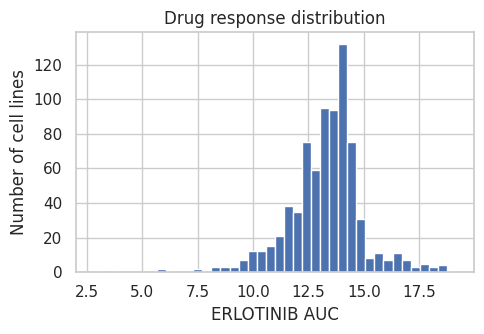

In [23]:
plt.figure(figsize=(5, 3.5))
plt.hist(y, bins=40, edgecolor='white')
plt.xlabel(f'{target} AUC')
plt.ylabel('Number of cell lines')
plt.title('Drug response distribution')
plt.tight_layout()
# AUC가 낮을수록 항암제 반응성 좋음

### 5. 평가 함수 만들기

회귀 성능은 한 가지 지표만 보면 놓치는 부분이 있습니다.

- **PCC**: 실제값과 예측값의 선형 상관
- **SCC**: 순위 기반 상관
- **R2**: 설명된 분산 비율
- **MAE/RMSE**: 예측 오차의 크기


In [24]:
def regression_scores(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        pcc = np.nan
        scc = np.nan
    else:
        pcc = pearsonr(y_true, y_pred)[0]
        scc = spearmanr(y_true, y_pred)[0]

    return {
        'PCC': pcc,
        'SCC': scc,
        'R2': met.r2_score(y_true, y_pred),
        'MAE': met.mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(met.mean_squared_error(y_true, y_pred))),
    }


def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs predicted'):
    scores = regression_scores(y_true, y_pred)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
  #산점도 만든것

    plt.figure(figsize=(4.5, 4.5))
    plt.scatter(y_true, y_pred, alpha=0.75, s=32)
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.text(
        0.04, 0.96,
        f"PCC={scores['PCC']:.3f}\nR2={scores['R2']:.3f}\nRMSE={scores['RMSE']:.3f}",
        transform=plt.gca().transAxes,
        va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.85),
    )
    plt.tight_layout()
    return scores


### 6. Train/Test split: ElasticNet 기본 모델

ElasticNet은 L1(Lasso)과 L2(Ridge) 규제를 함께 사용하는 선형 회귀 모델입니다. 유전자 수가 샘플 수보다 훨씬 많은 데이터에서 기본 모델로 쓰기 좋습니다.


#### 학습 절차

<div style="display:flex; gap:24px; align-items:flex-start;">
  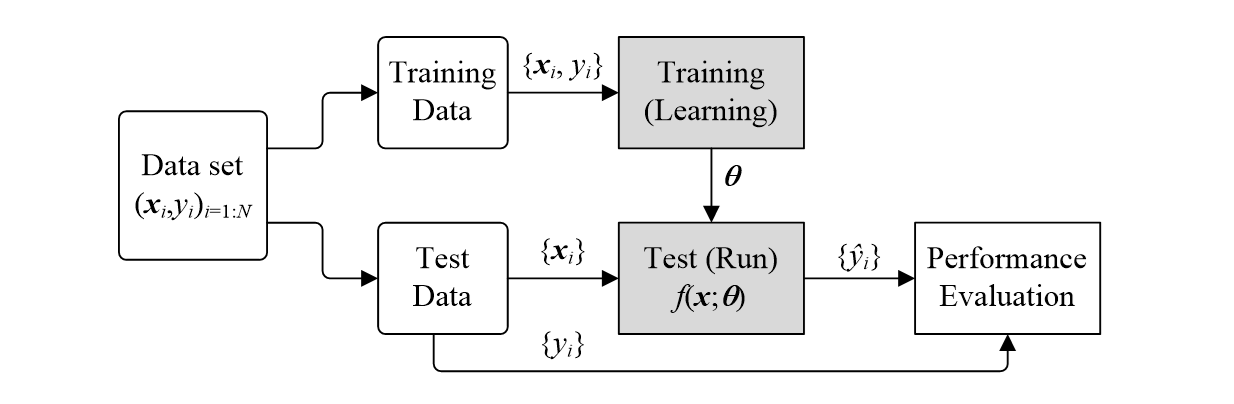
</div>

#### 선형 회귀 모형 그림

<div style="display:flex; gap:24px; align-items:flex-start;">
  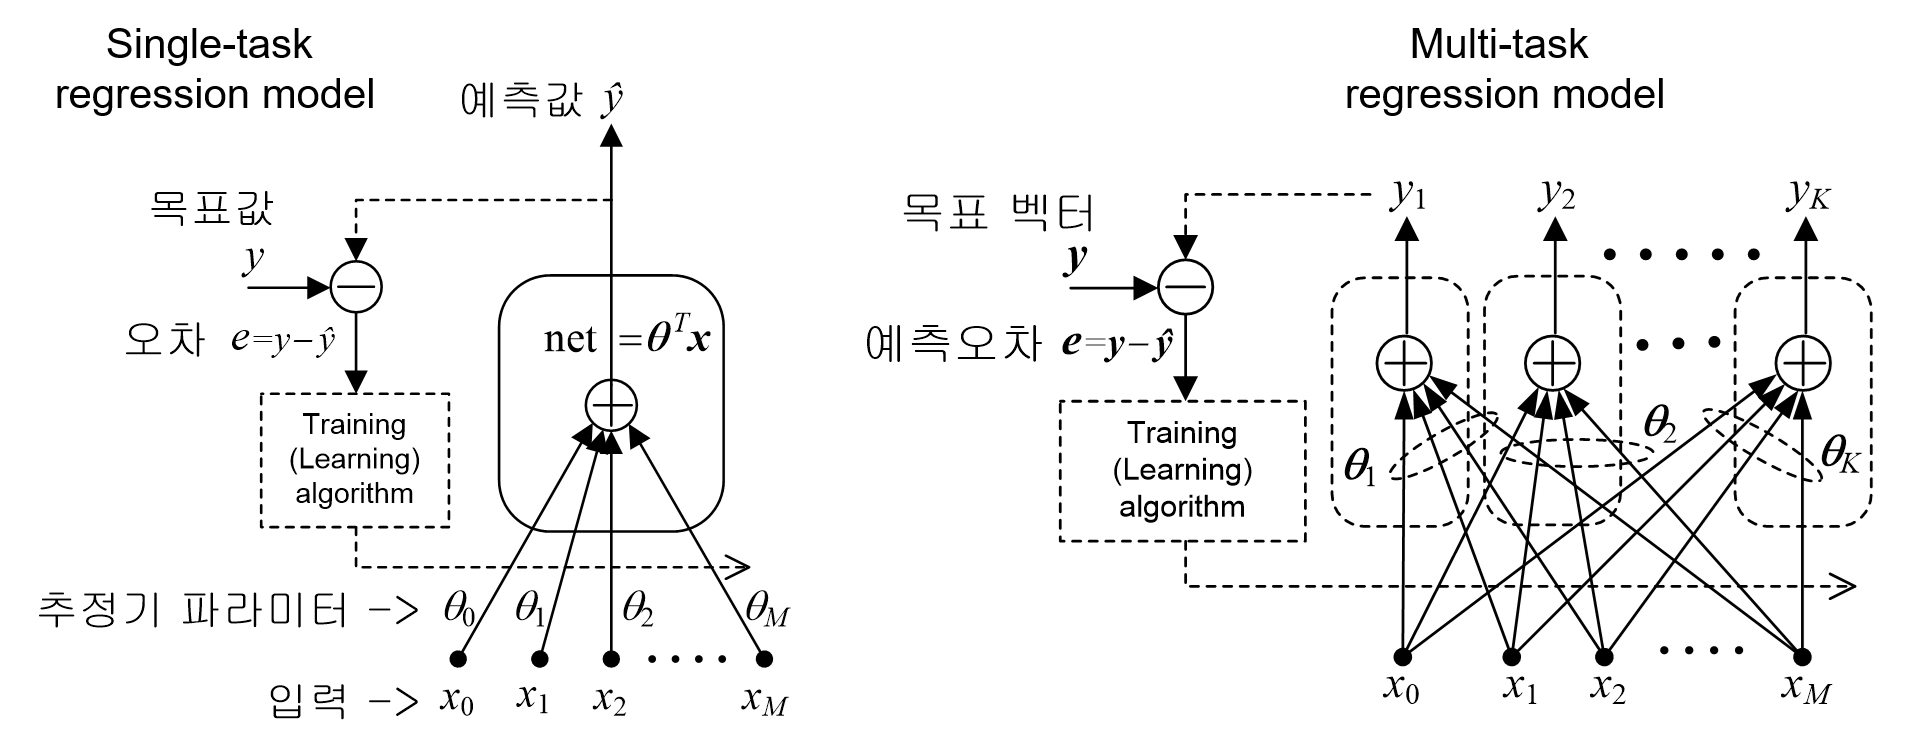  
</div>


## Model:

### (Binary) Linear regression with $l_1$ and $l_2$ penalty (ElasticNet)
model description: https://scikit-learn.org/stable/modules/linear_model.html#
<br>
model usage: https://scikit-learn.org/stable/modules/linear_model.html#elastic-net

#### Model: $$ \hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) = {\bf{x}}^T_i {\boldsymbol{\theta}} + c $$
#### Cost to minimize (OLS): $$ \min_{{\boldsymbol{\theta}},c} \frac{1}{2n} \| \bf{y}-\hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) \|^2 $$
#### Cost to minimize (ElasticNet): $$ \min_{{\boldsymbol{\theta}},c} \frac{1}{2n} \| \bf{y}-\hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) \|^2 + \alpha \left( \frac{1-\rho}{2} {\boldsymbol{\theta}}^T{\boldsymbol{\theta}} + \rho \| {\boldsymbol{\theta}} \|_1 \right) $$
where
1. $\alpha$ controls the relative weight between RSS (1st term) and penaties (2nd and 3rd terms).
2. $\rho$ controls the relative weight between $l_1$ and $l_2$ penalty. $\rho = 1$ corresponds to LASSO while $\rho=0$ to Ridge.
3. $C \rightarrow \infty $ means no penalty.
<br>


In [25]:
X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

elastic_net = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.02, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])
## alpha = 0 => OLS
## alpha != 0 and l1_ratio = 1 => LASSO
## alpha != 0 and l1_ratio = 0 => Ridge

elastic_net.fit(X_train, y_train)
y_train_pred = elastic_net.predict(X_train)
y_test_pred = elastic_net.predict(X_test)

train_scores = regression_scores(y_train, y_train_pred)
test_scores = regression_scores(y_test, y_test_pred)

pd.DataFrame([train_scores, test_scores], index=['train', 'test'])


,PCC,SCC,R2,MAE,RMSE
train,0.958248,0.936277,0.890040,0.421650,0.559656
test,0.444243,0.401464,0.179403,1.359274,1.815399


{'PCC': np.float64(0.4442432926243533),
 'SCC': np.float64(0.40146418600707656),
 'R2': 0.1794032507895067,
 'MAE': 1.359273569589817,
 'RMSE': 1.8153992659996594}

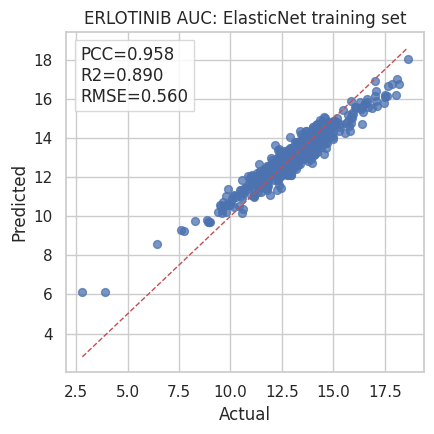

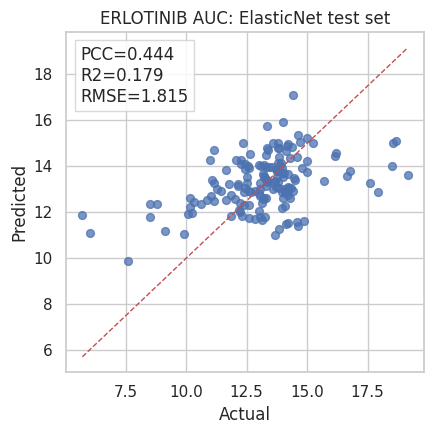

In [26]:
plot_actual_vs_predicted(y_train, y_train_pred, title=f'{target} AUC: ElasticNet training set')
plot_actual_vs_predicted(y_test, y_test_pred, title=f'{target} AUC: ElasticNet test set')


#### 실습 A

아래 값을 바꿔가며 test set 성능이 어떻게 달라지는지 확인하세요.

- `alpha`: 규제 강도
- `l1_ratio`: 1이면 Lasso, 0이면 Ridge에 가까움
- `test_size`: 테스트 데이터 비율


In [27]:
# 실습 A: 하이퍼파라미터를 바꿔보세요.
practice_alpha = 0.02
practice_l1_ratio = 1.0
practice_test_size = 0.2

X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X_df, y, test_size=practice_test_size, random_state=RANDOM_STATE, shuffle=True
)

practice_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(
        alpha=practice_alpha,
        l1_ratio=practice_l1_ratio,
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

practice_model.fit(X_train, y_train)
y_train_pred = practice_model.predict(X_train)
y_test_pred = practice_model.predict(X_test)

practice_scores = pd.DataFrame(
    [
        regression_scores(y_train, y_train_pred),
        regression_scores(y_test, y_test_pred),
    ],
    index=['train', 'test'],
)

practice_scores.loc['gap(train-test)'] = practice_scores.loc['train'] - practice_scores.loc['test']
practice_scores


,PCC,SCC,R2,MAE,RMSE
train,0.958248,0.936277,0.890040,0.421650,0.559656
test,0.444243,0.401464,0.179403,1.359274,1.815399
gap(train-test),0.514004,0.534813,0.710637,-0.937623,-1.255743


In [28]:
r2_gap = practice_scores.loc['gap(train-test)', 'R2']
rmse_gap = practice_scores.loc['gap(train-test)', 'RMSE']

if r2_gap > 0.20 and rmse_gap < 0:
    overfit_message = 'Train 성능이 test 성능보다 많이 높습니다. 과적합 가능성이 큽니다.'
elif r2_gap > 0.10:
    overfit_message = 'Train 성능이 test 성능보다 다소 높습니다. 약한 과적합 가능성을 확인해보세요.'
else:
    overfit_message = 'Train과 test 성능 차이가 크지 않습니다. 이 분할에서는 과적합 신호가 뚜렷하지 않습니다.'

print(overfit_message)
print(f"R2 gap = {r2_gap:.3f}, RMSE gap(train-test) = {rmse_gap:.3f}")


Train 성능이 test 성능보다 많이 높습니다. 과적합 가능성이 큽니다.
R2 gap = 0.711, RMSE gap(train-test) = -1.256


### 7. Cross-validation

Train/test split은 한 번의 분할에 결과가 영향을 받을 수 있습니다. Cross-validation은 데이터를 여러 fold로 나누어 더 안정적인 일반화 성능을 추정합니다.


#### 교차검증 절차 모식도

<div style="display:flex; gap:24px; align-items:flex-start;">
  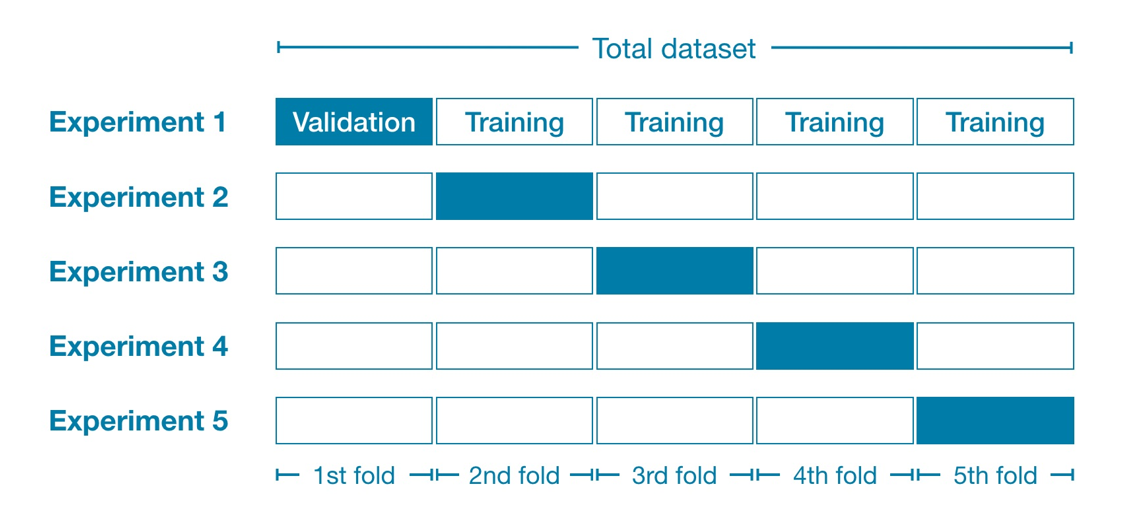  
</div>


In [29]:
NCV = 5
  # Cross Validation 몇개하는지 (5개)
cv = mod_sel.KFold(n_splits=NCV, shuffle=True, random_state=RANDOM_STATE)

cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.02, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

y_pred_cv = mod_sel.cross_val_predict(cv_model, X_df, y, cv=cv, n_jobs=-1)
cv_scores = regression_scores(y, y_pred_cv)
pd.Series(cv_scores, name=f'{NCV}-fold CV')


,5-fold CV
PCC,0.387435
SCC,0.406317
R2,0.031363
MAE,1.286025
RMSE,1.728389


{'PCC': np.float64(0.38743471513378436),
 'SCC': np.float64(0.40631656828885077),
 'R2': 0.03136259808866915,
 'MAE': 1.2860251672526242,
 'RMSE': 1.728388971004379}

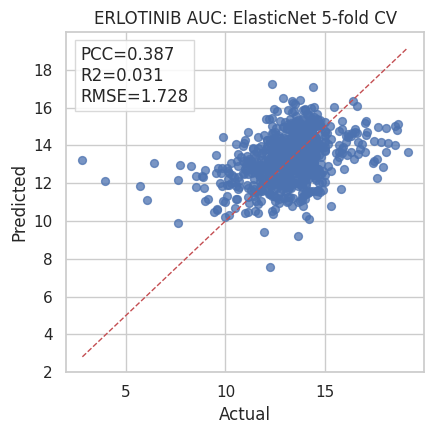

In [30]:
plot_actual_vs_predicted(y, y_pred_cv, title=f'{target} AUC: ElasticNet {NCV}-fold CV')


### 8. GridSearchCV로 하이퍼파라미터 최적화

여기서는 현재 선택한 단일 약물(`target`)에 대해 `alpha`와 `l1_ratio` 후보를 탐색합니다. 뒤쪽 과제에서는 이 아이디어를 확장해, 약물마다 별도로 GridSearchCV를 수행한 뒤 화학항암제와 표적항암제의 성능을 비교합니다.


In [31]:
base_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
])

param_grid = {
    'model__alpha': [0.001, 0.005, 0.01, 0.02, 0.05, 0.1],
    'model__l1_ratio': [0.2, 0.5, 0.8, 1.0],
}

gs = mod_sel.GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_df, y)
print('Best CV R2:', round(gs.best_score_, 3))
print('Best params:', gs.best_params_)

  # 알파값을 0.001 ~ 0.1로 했는데 0.1이 최적으로 나왔으니까, 뒤쪽을 좀더 확인해 봐야한다. ( L1_ratio 도 마찬가지 )

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV R2: 0.192
Best params: {'model__alpha': 0.1, 'model__l1_ratio': 1.0}


In [32]:
best_model = gs.best_estimator_
y_pred_best_cv = mod_sel.cross_val_predict(best_model, X_df, y, cv=cv, n_jobs=-1)
pd.Series(regression_scores(y, y_pred_best_cv), name='Best ElasticNet CV')


,Best ElasticNet CV
PCC,0.451403
SCC,0.420785
R2,0.203516
MAE,1.132619
RMSE,1.567290


In [33]:
best_model

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000,
                            random_state=5))])

{'PCC': np.float64(0.4514031930346613),
 'SCC': np.float64(0.4207848310197339),
 'R2': 0.2035161319387544,
 'MAE': 1.1326186744025424,
 'RMSE': 1.5672899949003685}

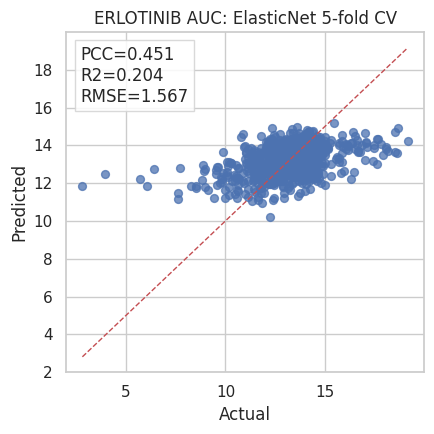

In [34]:
plot_actual_vs_predicted(y, y_pred_best_cv, title=f'{target} AUC: ElasticNet {NCV}-fold CV')


### 9. 여러 약물에 반복 적용하기

같은 ElasticNet 설정을 여러 약물에 반복 적용해 빠르게 성능을 비교합니다. 이 결과는 약물별 예측 난이도의 대략적인 차이를 보는 용도입니다. 더 공정한 비교를 위해서는 약물마다 하이퍼파라미터를 따로 최적화해야 하며, 그 작업은 과제에서 수행합니다.


In [35]:
def prepare_drug_response(
    drug,
    response_table=df_auc,
    feature_table=df_expression_feature,
    min_samples=50,
    add_mutation_features=True,
):
    if drug not in response_table.columns:
        raise ValueError(f'{drug} not found in response table.')

    y_raw = response_table[drug]
    valid = y_raw.notna() & np.isfinite(y_raw)
    if valid.sum() < min_samples:
        return None, None

    X_drug = feature_table.loc[valid].copy()
    y_drug = y_raw.loc[valid].astype(float).copy()

    if add_mutation_features:
        drug_target_genes = parse_target_genes(drug)
        X_mut_drug = make_target_mutation_features(df_mutation_info, drug_target_genes, X_drug.index)
        X_drug = pd.concat([X_drug, X_mut_drug], axis=1).copy()

    return X_drug, y_drug


def evaluate_drug_cv(
    drug,
    model,
    response_table=df_auc,
    feature_table=df_expression_feature,
    cv=cv,
    min_samples=50,
    add_mutation_features=True,
):
    X_drug, y_drug = prepare_drug_response(
        drug,
        response_table=response_table,
        feature_table=feature_table,
        min_samples=min_samples,
        add_mutation_features=add_mutation_features,
    )
    if X_drug is None:
        return None

    y_pred = mod_sel.cross_val_predict(model, X_drug, y_drug, cv=cv, n_jobs=-1)
    result = regression_scores(y_drug, y_pred)
    result.update({'drug': drug, 'n_samples': len(y_drug), 'n_features': X_drug.shape[1]})
    return result


In [36]:
drugs_to_test = [
    'CLOFARABINE',
    'CYTARABINE HYDROCHLORIDE',
    'DECITABINE',
    'DOXORUBICIN',
    'TOPOTECAN',
    'ETOPOSIDE',
    'PACLITAXEL',
    'CARBOPLATIN',
    'VINCRISTINE',
]
drugs_to_test = [drug for drug in drugs_to_test if drug in df_auc.columns]

default_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

results = []
for drug in drugs_to_test:
    print('Evaluating:', drug)
    result = evaluate_drug_cv(drug, default_enet)
    if result is not None:
        results.append(result)

result_df = pd.DataFrame(results).set_index('drug').sort_values('PCC', ascending=False)
result_df


Evaluating: CLOFARABINE
Evaluating: CYTARABINE HYDROCHLORIDE
Evaluating: DECITABINE
Evaluating: DOXORUBICIN
Evaluating: TOPOTECAN
Evaluating: ETOPOSIDE
Evaluating: PACLITAXEL
Evaluating: CARBOPLATIN
Evaluating: VINCRISTINE


,PCC,SCC,R2,MAE,RMSE,n_samples,n_features
drug,,,,,,,
CYTARABINE HYDROCHLORIDE,0.740978,0.668500,0.548855,1.576649,2.123659,778,3268
CLOFARABINE,0.735352,0.683743,0.540610,1.730874,2.228969,794,3268
DECITABINE,0.735066,0.529878,0.540310,1.247920,1.805591,789,3271
DOXORUBICIN,0.699875,0.671554,0.489267,1.346552,1.681549,800,3271
ETOPOSIDE,0.690366,0.611518,0.476308,1.122128,1.490759,780,3271
VINCRISTINE,0.681751,0.675568,0.463704,2.073341,2.635489,808,3268
TOPOTECAN,0.668170,0.662381,0.446428,1.495395,1.939452,794,3271
PACLITAXEL,0.606361,0.621719,0.365907,2.374071,3.023516,769,3268
CARBOPLATIN,0.223267,0.206115,0.048462,0.576554,0.874890,783,3268


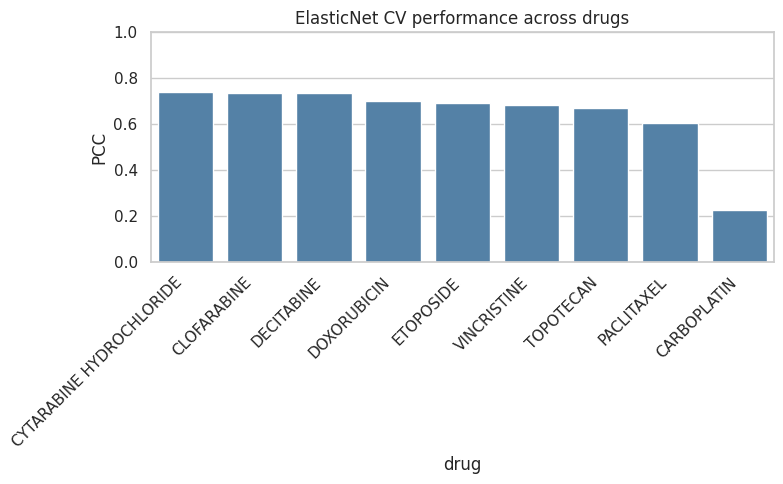

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=result_df.reset_index(), x='drug', y='PCC', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('ElasticNet CV performance across drugs')
plt.tight_layout()


#### 실습 B

`drugs_to_test`에 원하는 약물을 추가해보세요. 처음에는 `chemo_summary`의 화학항암제 후보를 3-5개 골라 비교하고, 그 다음 `targeted_summary`의 표적항암제 후보를 추가해 성능 차이를 비교해보면 좋습니다.


In [38]:
# 실습 B: 분석할 약물 후보를 직접 골라보세요.
print('Chemical anticancer drug candidates')
display(chemo_summary)

print('Targeted anticancer drug candidates')
display(targeted_summary)


Chemical anticancer drug candidates


,cpd_name,target_or_activity_of_compound,gene_symbol_of_protein_target,inclusion_rationale,n_AUC_samples
cpd_id,,,,,
VINCRISTINE,VINCRISTINE,inhibitor of mictrotubule assembly,NaN,std-of-care,808
DOXORUBICIN,DOXORUBICIN,inhibitor of topoisomerase II,TOP2A,std-of-care,800
TOPOTECAN,TOPOTECAN,inhibitor of topoisomerase I,TOP1,std-of-care,794
CLOFARABINE,CLOFARABINE,inducer of DNA damage,NaN,std-of-care,794
DECITABINE,DECITABINE,inhibitor of DNA methyltransferase,DNMT1,chromatin;CTEP;std-of-care,789
CARBOPLATIN,CARBOPLATIN,inducer of DNA damage,NaN,std-of-care,783
ETOPOSIDE,ETOPOSIDE,inhibitor of topoisomerase II,TOP2A,pilot-set;std-of-care,780
CYTARABINE HYDROCHLORIDE,CYTARABINE HYDROCHLORIDE,inducer of DNA damage,NaN,std-of-care,778
OXALIPLATIN,OXALIPLATIN,DNA alkylator; organoplatinum reagent,NaN,std-of-care,774


Targeted anticancer drug candidates


,cpd_name,gene_symbol_of_protein_target,target_or_activity_of_compound,inclusion_rationale,n_AUC_samples
cpd_id,,,,,
NERATINIB,NERATINIB,EGFR;ERBB2,inhibitor of EGFR and HER2,kinome;pilot-set,791
DASATINIB,DASATINIB,EPHA2;KIT;LCK;SRC;YES1,"inhibitor of SRC, YES1, EPHA2, c-KIT, and LCK",CTEP;kinome;std-of-care,786
AXITINIB,AXITINIB,FLT1;FLT3;KDR;KIT;PDGFRA;PDGFRB,"inhibitor of VEGFRs, c-KIT, and PDGFR alpha an...",kinome,778
ERLOTINIB,ERLOTINIB,EGFR;ERBB2,inhibitor of EGFR and HER2,CTEP;kinome;std-of-care,778
SUNITINIB,SUNITINIB,FLT1;FLT3;KDR;KIT;PDGFRA;PDGFRB,"inhibitor of VEGFRs, c-KIT, and PDGFR alpha an...",CTEP;kinome,773
CRIZOTINIB,CRIZOTINIB,ALK;MET,inhibitor of c-MET and ALK,kinome;std-of-care,769
BOSUTINIB,BOSUTINIB,ABL1;SRC,inhibitor of SRC and ABL1,kinome,766
GEFITINIB,GEFITINIB,AKT1;EGFR,inhibitor of EGFR and AKT1,chromatin;CTEP;kinome;std-of-care,759
CABOZANTINIB,CABOZANTINIB,FLT3;KDR;MET;RET,"inhibitor of c-MET, VEGFR2/3, and RET",CTEP;kinome,755


In [39]:
drugs_to_test = [
    'AFATINIB',
    'AXITINIB',
    'BOSUTINIB',
    'CABOZANTINIB',
    'CRIZOTINIB',
    'DASATINIB',
    'ERLOTINIB',
    'GEFITINIB',
    'LAPATINIB',
    'NERATINIB',
    'SUNITINIB',
]
drugs_to_test = [drug for drug in drugs_to_test if drug in df_auc.columns]

default_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

results = []
for drug in drugs_to_test:
    print('Evaluating:', drug)
    result = evaluate_drug_cv(drug, default_enet)
    if result is not None:
        results.append(result)

result_df = pd.DataFrame(results).set_index('drug').sort_values('PCC', ascending=False)
result_df


Evaluating: AFATINIB
Evaluating: AXITINIB
Evaluating: BOSUTINIB
Evaluating: CABOZANTINIB
Evaluating: CRIZOTINIB
Evaluating: DASATINIB
Evaluating: ERLOTINIB
Evaluating: GEFITINIB
Evaluating: LAPATINIB
Evaluating: NERATINIB
Evaluating: SUNITINIB


,PCC,SCC,R2,MAE,RMSE,n_samples,n_features
drug,,,,,,,
CRIZOTINIB,0.545516,0.483180,0.295894,0.858790,1.195500,769,3274
AXITINIB,0.526970,0.523089,0.277560,1.002983,1.442065,778,3286
AFATINIB,0.475242,0.444174,0.223307,1.315026,1.821057,696,3274
ERLOTINIB,0.451403,0.420785,0.203516,1.132619,1.567290,778,3274
DASATINIB,0.448096,0.466506,0.191353,1.921148,2.550768,786,3283
LAPATINIB,0.420152,0.421688,0.175560,1.098837,1.498029,734,3274
BOSUTINIB,0.409299,0.419480,0.167277,0.945846,1.284191,766,3274
SUNITINIB,0.403143,0.393908,0.162521,0.774110,1.166455,773,3286
GEFITINIB,0.398105,0.335716,0.157690,1.159188,1.615550,759,3274


### Discussion: 표적항암제 예측은 왜 더 어려울까?

화학항암제는 DNA damage, microtubule assembly, topoisomerase inhibition처럼 비교적 넓은 세포 상태와 증식 특성에 영향을 받는 경우가 많습니다. 그래서 전체 유전자 발현 패턴만으로도 어느 정도 반응성을 예측할 수 있습니다. 반면 표적항암제는 특정 표적 단백질이나 신호전달 경로의 활성에 더 강하게 의존하므로, 단순한 basal gene expression만으로는 반응성을 충분히 설명하기 어려울 수 있습니다.

생각해볼 질문:

1. 표적항암제 반응 예측에 유전자 발현 외에 어떤 정보가 더 필요할까요?
2. EGFR inhibitor 반응을 예측하려면 EGFR 발현량만 보면 충분할까요, 아니면 EGFR mutation/amplification 정보가 필요할까요?
3. 같은 표적을 가진 약물이라도 세포주의 lineage나 downstream pathway 상태에 따라 반응이 달라질 수 있을까요?
4. 표적항암제 모델 성능을 높이기 위해 mutation, copy number variation, phosphoproteomics, pathway activity score 중 무엇을 추가하면 좋을까요?
5. 샘플 수가 비슷한데도 화학항암제와 표적항암제의 예측 성능이 다르다면, 그 차이는 데이터 품질 문제일까요, 생물학적 특이성 때문일까요?

토의 방향: `chemo_summary`와 `targeted_summary`에서 약물 작용기전, 표적 유전자, AUC 샘플 수를 비교하고, 성능 차이가 큰 약물 1-2개를 골라 왜 그런 차이가 생겼는지 가설을 세워보세요.


### 10. 모델 비교

같은 약물에 대해 ElasticNet, Ridge, Lasso, RandomForest를 비교합니다. RandomForest는 스케일링이 필수는 아니지만, 여기서는 모델별 파이프라인을 명확히 분리합니다.


In [40]:
models = {
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.Lasso(alpha=0.1, max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

model_results = []
for model_name, model in models.items():
    print('Evaluating model:', model_name)
    y_pred = mod_sel.cross_val_predict(model, X_df, y, cv=cv, n_jobs=-1)
    row = regression_scores(y, y_pred)
    row.update({'model': model_name})
    model_results.append(row)

model_result_df = pd.DataFrame(model_results).set_index('model').sort_values('PCC', ascending=False)
model_result_df


Evaluating model: ElasticNet
Evaluating model: Ridge
Evaluating model: Lasso
Evaluating model: RandomForest


,PCC,SCC,R2,MAE,RMSE
model,,,,,
RandomForest,0.459819,0.442216,0.210280,1.100343,1.560621
ElasticNet,0.451403,0.420785,0.203516,1.132619,1.567290
Lasso,0.451403,0.420785,0.203516,1.132619,1.567290
Ridge,0.418714,0.410217,0.067227,1.283662,1.696090


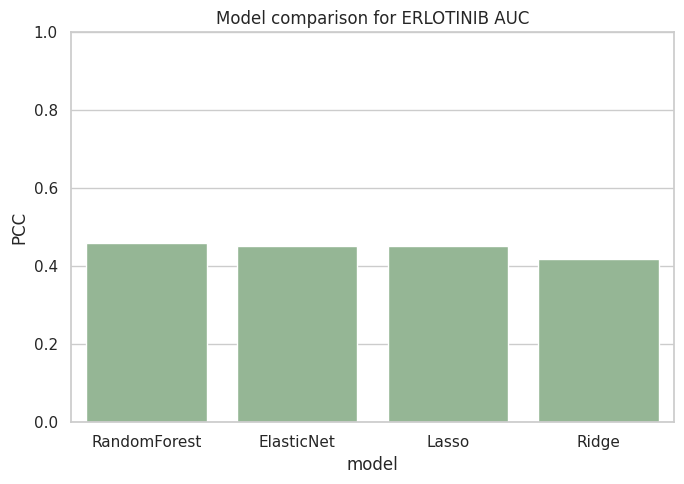

In [41]:
plt.figure(figsize=(7, 5))
sns.barplot(data=model_result_df.reset_index(), x='model', y='PCC', color='darkseagreen')
plt.ylim(0, 1)
plt.title(f'Model comparison for {target} AUC')
plt.tight_layout()


### 11. 차원 축소 시각화

PCA와 t-SNE를 사용해 세포주 유전자 발현 패턴을 2차원으로 살펴봅니다. 같은 좌표를 약물 반응값(AUC)과 `lineage_subtype`으로 각각 색칠하면, 특정 암종/아형에서 해당 항암제 반응이 더 강한지 탐색할 수 있습니다. 일반적으로 AUC가 낮을수록 약물에 더 민감한 반응으로 해석합니다. t-SNE는 실행 시간이 걸릴 수 있으므로 샘플 수가 클 때는 일부만 사용합니다.


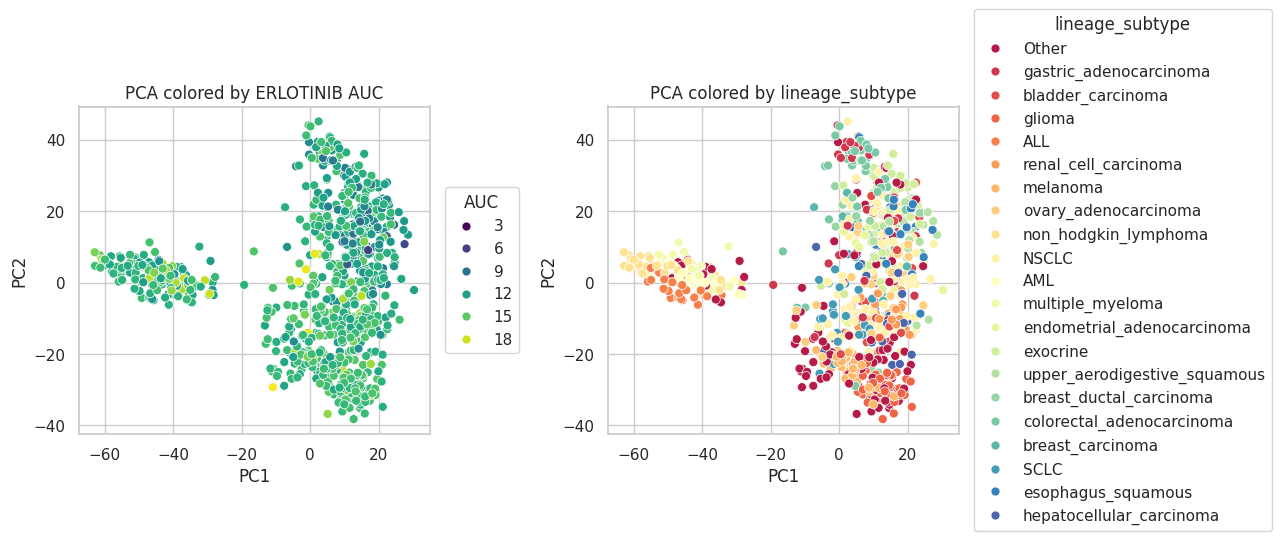

In [42]:
subtype_col = 'lineage_subtype' if 'lineage_subtype' in info_sel.columns else 'lineage'
TOP_N_SUBTYPES = 20

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_df))

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_df.index)
pca_df['response'] = y.values
pca_df[subtype_col] = info_sel[subtype_col].fillna('Unknown').values

top_subtypes = pca_df[subtype_col].value_counts().head(TOP_N_SUBTYPES).index
pca_df['subtype_for_plot'] = np.where(pca_df[subtype_col].isin(top_subtypes), pca_df[subtype_col], 'Other')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='response', palette='viridis', s=42, ax=axes[0])
axes[0].set_title(f'PCA colored by {target} AUC')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='AUC')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='subtype_for_plot', s=42, ax=axes[1], palette = "Spectral")
axes[1].set_title(f'PCA colored by {subtype_col}')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title=subtype_col)

plt.tight_layout()


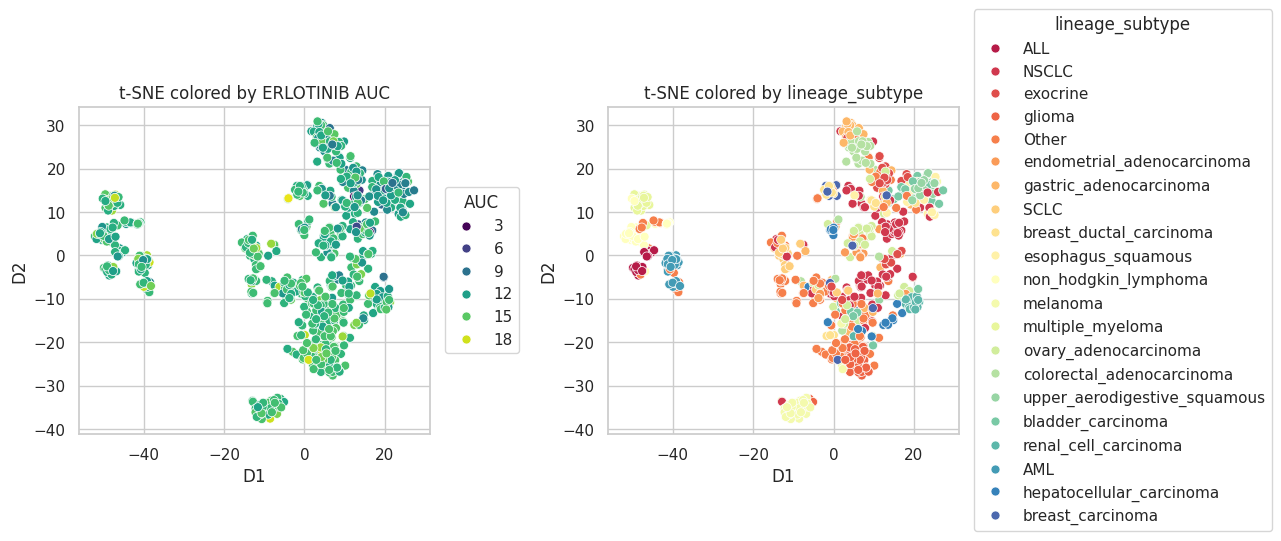

In [43]:
# t-SNE는 시간이 걸릴 수 있습니다. 필요하면 max_tsne_samples를 줄이세요.
max_tsne_samples = 800
sample_index = X_df.sample(min(max_tsne_samples, len(X_df)), random_state=RANDOM_STATE).index

X_tsne_input = StandardScaler().fit_transform(X_df.loc[sample_index])
X_2d_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca',
    perplexity=30,
    random_state=RANDOM_STATE,
).fit_transform(X_tsne_input)

tsne_df = pd.DataFrame(X_2d_tsne, columns=['D1', 'D2'], index=sample_index)
tsne_df['response'] = y.loc[sample_index].values
tsne_df[subtype_col] = df_cl_info.reindex(sample_index)[subtype_col].fillna('Unknown').values
tsne_df['subtype_for_plot'] = np.where(tsne_df[subtype_col].isin(top_subtypes), tsne_df[subtype_col], 'Other')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=tsne_df, x='D1', y='D2', hue='response', palette='viridis', s=42, ax=axes[0])
axes[0].set_title(f't-SNE colored by {target} AUC')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='AUC')

sns.scatterplot(data=tsne_df, x='D1', y='D2', hue='subtype_for_plot', s=42, ax=axes[1], palette = "Spectral")
axes[1].set_title(f't-SNE colored by {subtype_col}')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title=subtype_col)

plt.tight_layout()


#### 암종 아형별 약물 반응 분포

아래 표와 boxplot은 `lineage_subtype`별 AUC 분포를 요약합니다. 샘플 수가 너무 적은 아형은 해석이 불안정하므로 기본값은 5개 이상 샘플이 있는 아형만 표시합니다. AUC가 낮은 아형일수록 해당 약물에 더 민감할 가능성이 있습니다.


,n_samples,mean_AUC,median_AUC,std_AUC
lineage_subtype,,,,
upper_aerodigestive_squamous,30,11.043707,11.4495,1.851206
cholangiocarcinoma,6,11.318750,11.6640,2.155299
CML,12,12.105000,11.9090,0.965923
esophagus_squamous,23,12.179948,12.4660,1.315199
bladder_carcinoma,23,12.253170,12.7160,2.033668
endometrial_adenocarcinoma,21,12.955143,12.9320,0.967922
hodgkin_lymphoma,6,13.124667,13.0095,0.648695
exocrine,35,13.145594,13.1800,1.279157
NSCLC,106,12.727537,13.1815,2.229906


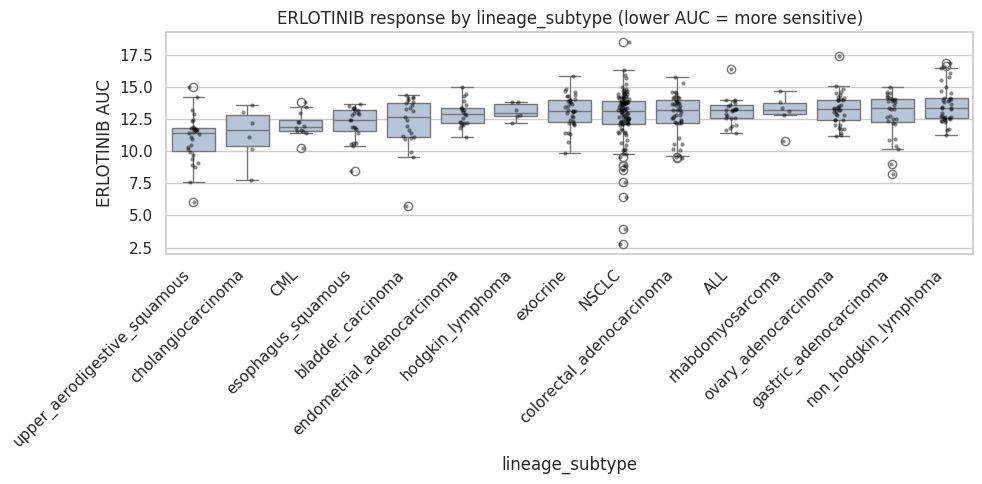

In [44]:
min_subtype_samples = 5

subtype_response_df = pd.DataFrame({
    'response': y,
    subtype_col: info_sel[subtype_col].fillna('Unknown'),
})

subtype_counts = subtype_response_df[subtype_col].value_counts()
subtypes_to_show = subtype_counts[subtype_counts >= min_subtype_samples].index
subtype_response_df = subtype_response_df[subtype_response_df[subtype_col].isin(subtypes_to_show)].copy()

subtype_response_summary = (
    subtype_response_df
    .groupby(subtype_col)['response']
    .agg(n_samples='size', mean_AUC='mean', median_AUC='median', std_AUC='std')
    .sort_values('median_AUC')
)
display(subtype_response_summary.head(15))

plot_order = subtype_response_summary.head(15).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=subtype_response_df, x=subtype_col, y='response', order=plot_order, color='lightsteelblue')
sns.stripplot(data=subtype_response_df, x=subtype_col, y='response', order=plot_order, color='black', size=3, alpha=0.45)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'{target} AUC')
plt.title(f'{target} response by {subtype_col} (lower AUC = more sensitive)')
plt.tight_layout()


### 12. Feature importance: ElasticNet 회귀계수 확인

SHAP까지 사용하지 않더라도, 선형모형에서는 회귀계수(`coef_`)를 통해 어떤 feature가 예측에 크게 기여했는지 살펴볼 수 있습니다. 아래 코드는 8번 GridSearchCV에서 찾은 `best_model`을 전체 데이터에 다시 학습한 뒤, 절대값이 큰 회귀계수를 확인합니다.

주의: 이 모델은 `StandardScaler` 이후의 값을 사용하므로, 계수는 스케일링된 유전자 발현 feature 기준입니다. AUC 예측에서는 계수가 양수이면 해당 유전자 발현이 높을수록 예측 AUC가 커지는 방향, 즉 상대적으로 덜 민감한 방향으로 해석할 수 있고, 계수가 음수이면 발현이 높을수록 예측 AUC가 낮아지는 방향, 즉 더 민감한 방향으로 해석할 수 있습니다.


In [45]:
# 8번 GridSearchCV에서 얻은 best_model을 전체 데이터로 다시 학습합니다.
# best_model이 아직 없다면 8번 섹션을 먼저 실행하세요.
importance_model = best_model
importance_model.fit(X_df, y)

feature_names = np.array(X_df.columns)
coef = importance_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False)

nonzero_coef_df = coef_df[coef_df['coef'] != 0].copy()
print('Number of non-zero coefficient features:', len(nonzero_coef_df))
display(coef_df.head(20))


Number of non-zero coefficient features: 72


,feature,coef,abs_coef
3270,mut_EGFR_hotspot,-0.169099,0.169099
743,PPP1R14C,-0.099485,0.099485
3218,RPS6KB2,0.095199,0.095199
713,VAV3,-0.091042,0.091042
504,DSC2,-0.088127,0.088127
3043,CASP6,-0.083945,0.083945
160,MDFI,-0.080424,0.080424
1157,CHI3L1,0.079520,0.079520
1480,TTC22,-0.074928,0.074928
1611,ZNF439,0.066739,0.066739


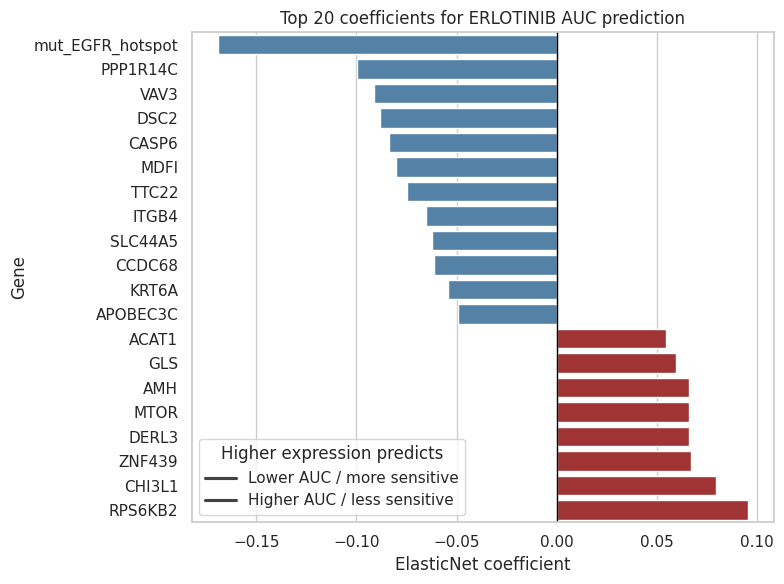

In [46]:
top_n = 20
top_coef_df = coef_df.head(top_n).copy().sort_values('coef')

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_coef_df,
    x='coef',
    y='feature',
    hue=top_coef_df['coef'] > 0,
    dodge=False,
    palette={True: 'firebrick', False: 'steelblue'},
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('ElasticNet coefficient')
plt.ylabel('Gene')
plt.title(f'Top {top_n} coefficients for {target} AUC prediction')
plt.legend(title='Higher expression predicts', labels=['Lower AUC / more sensitive', 'Higher AUC / less sensitive'])
plt.tight_layout()


#### 해석 질문

- 절대값이 큰 회귀계수를 가진 유전자들은 어떤 생물학적 기능을 가질까요?
- 양의 계수와 음의 계수를 가진 유전자는 약물 반응성 관점에서 어떻게 다르게 해석할 수 있을까요?
- `target`을 다른 항암제로 바꾸면 중요한 유전자 목록이 바뀌나요?
- 표적항암제의 경우, 표적 유전자 자체가 중요한 feature로 나타나나요? 그렇지 않다면 어떤 추가 정보가 필요할까요?


### 13. 선택 실습: XGBoost

XGBoost가 설치된 환경이라면 아래 셀을 실행해보세요. 설치되어 있지 않으면 자동으로 건너뜁니다.


,XGBoost CV
PCC,0.443255
SCC,0.435789
R2,0.196357
MAE,1.116853
RMSE,1.574318


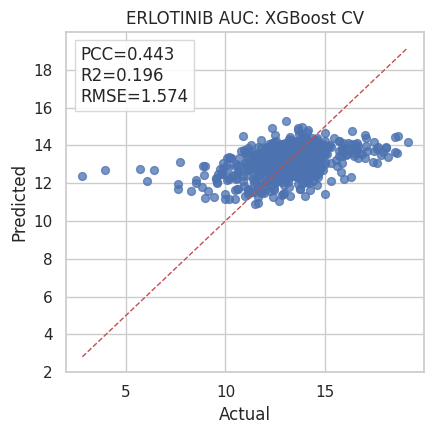

In [47]:
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.5,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    y_pred_xgb = mod_sel.cross_val_predict(xgb_model, X_df, y, cv=cv, n_jobs=-1)
    display(pd.Series(regression_scores(y, y_pred_xgb), name='XGBoost CV'))
    plot_actual_vs_predicted(y, y_pred_xgb, title=f'{target} AUC: XGBoost CV')
except ImportError:
    print('xgboost is not installed. To run this optional section, install xgboost first.')


### 14. 과제: 약물별 GridSearchCV 후 화학항암제와 표적항암제 비교

다음 항목을 포함해 짧은 분석 보고서를 작성하세요.

1. `chemo_summary`에서 화학항암제 3개, `targeted_summary`에서 표적항암제 3개를 선택한다.
2. 각 약물마다 별도로 ElasticNet `GridSearchCV`를 수행하여 `alpha`, `l1_ratio`를 최적화한다.
3. 각 약물의 best parameter와 cross-validation 성능(PCC, SCC, R2, MAE, RMSE)을 표로 정리한다.
4. 결과표에 `drug_type`, `n_samples`, `best_alpha`, `best_l1_ratio`를 포함한다.
5. 화학항암제와 표적항암제의 평균 또는 중앙값 PCC를 비교한다.
6. 가장 잘 예측된 약물 1개와 가장 예측이 어려운 약물 1개의 actual-vs-predicted plot을 제시한다.
7. 성능 차이가 발생한 이유를 샘플 수, 반응값 분포, 약물 작용기전, 추가 omics 정보 필요성 관점에서 해석한다.

참고: 아래 코드는 각 약물에서 하이퍼파라미터 선택과 성능 평가를 같은 데이터로 수행하므로 성능이 약간 낙관적으로 보일 수 있습니다. 연구 수준의 엄밀한 평가는 nested cross-validation으로 수행합니다.


In [48]:
# 과제 템플릿: 약물별 GridSearchCV 후 성능 비교
homework_chemo_drugs = ['CLOFARABINE', 'DOXORUBICIN', 'PACLITAXEL']
homework_targeted_drugs = ['ERLOTINIB', 'GEFITINIB', 'LAPATINIB']

homework_drug_groups = {
    'chemotherapy': [drug for drug in homework_chemo_drugs if drug in df_auc.columns],
    'targeted': [drug for drug in homework_targeted_drugs if drug in df_auc.columns],
}

homework_param_grid = {
    'model__alpha': [0.005, 0.01, 0.02, 0.05, 0.1],
    'model__l1_ratio': [0.5, 0.8, 1.0],
}


def evaluate_drug_with_gridsearch(drug, drug_type, response_table=df_auc, feature_table=df_expression_feature, cv=cv):
    X_drug, y_drug = prepare_drug_response(
        drug,
        response_table=response_table,
        feature_table=feature_table,
        min_samples=50,
        add_mutation_features=True,
    )
    if X_drug is None:
        return None, None

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
    ])

    grid = mod_sel.GridSearchCV(
        estimator=model,
        param_grid=homework_param_grid,
        scoring='r2',
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_drug, y_drug)

    best_model = grid.best_estimator_
    y_pred = mod_sel.cross_val_predict(best_model, X_drug, y_drug, cv=cv, n_jobs=-1)

    result = regression_scores(y_drug, y_pred)
    result.update({
        'drug': drug,
        'drug_type': drug_type,
        'n_samples': len(y_drug),
        'best_alpha': grid.best_params_['model__alpha'],
        'best_l1_ratio': grid.best_params_['model__l1_ratio'],
        'best_grid_R2': grid.best_score_,
    })
    pred_df = pd.DataFrame({'actual': y_drug, 'predicted': y_pred})
    return result, pred_df


homework_rows = []
homework_predictions = {}

for drug_type, drug_list in homework_drug_groups.items():
    for drug in drug_list:
        print(f'GridSearchCV for {drug} ({drug_type})')
        row, pred_df = evaluate_drug_with_gridsearch(drug, drug_type)
        if row is not None:
            homework_rows.append(row)
            homework_predictions[drug] = pred_df

homework_result_df = (
    pd.DataFrame(homework_rows)
    .set_index('drug')
    .sort_values(['drug_type', 'PCC'], ascending=[True, False])
)
homework_result_df


GridSearchCV for CLOFARABINE (chemotherapy)
GridSearchCV for DOXORUBICIN (chemotherapy)
GridSearchCV for PACLITAXEL (chemotherapy)
GridSearchCV for ERLOTINIB (targeted)
GridSearchCV for GEFITINIB (targeted)
GridSearchCV for LAPATINIB (targeted)


,PCC,SCC,R2,MAE,RMSE,drug_type,n_samples,best_alpha,best_l1_ratio,best_grid_R2
drug,,,,,,,,,,
CLOFARABINE,0.735352,0.683743,0.540610,1.730874,2.228969,chemotherapy,794,0.1,1.0,0.534928
DOXORUBICIN,0.699875,0.671554,0.489267,1.346552,1.681549,chemotherapy,800,0.1,1.0,0.485599
PACLITAXEL,0.606361,0.621719,0.365907,2.374071,3.023516,chemotherapy,769,0.1,1.0,0.360942
ERLOTINIB,0.451403,0.420785,0.203516,1.132619,1.567290,targeted,778,0.1,1.0,0.192465
LAPATINIB,0.420152,0.421688,0.175560,1.098837,1.498029,targeted,734,0.1,1.0,0.169611
GEFITINIB,0.398105,0.335716,0.157690,1.159188,1.615550,targeted,759,0.1,1.0,0.146235


In [49]:
homework_group_summary = homework_result_df.groupby('drug_type')[['PCC', 'SCC', 'R2', 'MAE', 'RMSE']].agg(['mean', 'median'])
homework_group_summary


PCC                 SCC                  R2            \
                  mean    median      mean    median      mean    median   
drug_type                                                                  
chemotherapy  0.680529  0.699875  0.659006  0.671554  0.465261  0.489267   
targeted      0.423220  0.420152  0.392730  0.420785  0.178922  0.175560   

                   MAE                RMSE            
                  mean    median      mean    median  
drug_type                                             
chemotherapy  1.817166  1.730874  2.311345  2.228969  
targeted      1.130215  1.132619  1.560290  1.567290

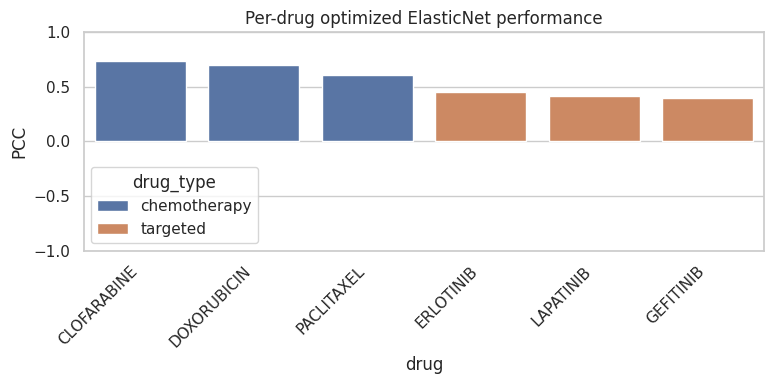

In [50]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=homework_result_df.reset_index(),
    x='drug',
    y='PCC',
    hue='drug_type',
)
plt.xticks(rotation=45, ha='right')
plt.ylim(-1, 1)
plt.title('Per-drug optimized ElasticNet performance')
plt.tight_layout()


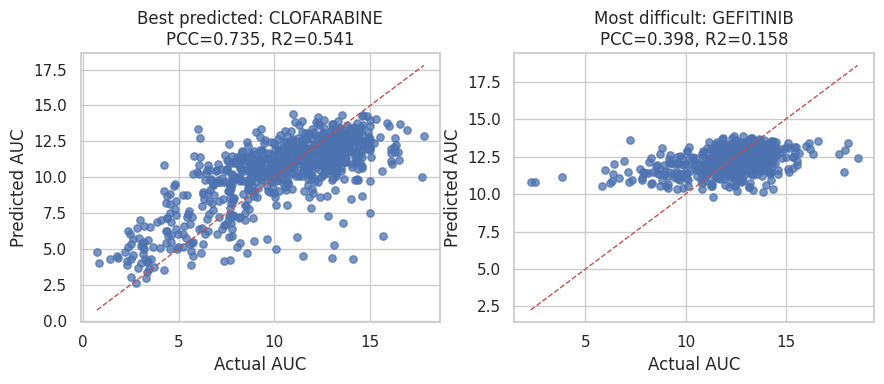

In [51]:
best_drug = homework_result_df['PCC'].idxmax()
worst_drug = homework_result_df['PCC'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, drug_name, title in zip(axes, [best_drug, worst_drug], ['Best predicted', 'Most difficult']):
    pred_df = homework_predictions[drug_name]
    scores = regression_scores(pred_df['actual'], pred_df['predicted'])
    lo = min(pred_df['actual'].min(), pred_df['predicted'].min())
    hi = max(pred_df['actual'].max(), pred_df['predicted'].max())
    ax.scatter(pred_df['actual'], pred_df['predicted'], alpha=0.75, s=28)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_title(f"{title}: {drug_name}\nPCC={scores['PCC']:.3f}, R2={scores['R2']:.3f}")
    ax.set_xlabel('Actual AUC')
    ax.set_ylabel('Predicted AUC')

plt.tight_layout()


### 정리 질문

- Train/test split 결과와 cross-validation 결과 중 어느 쪽을 보고 모델의 일반화 성능을 말하는 것이 더 적절한가요?
- `alpha`가 커질수록 ElasticNet 모델의 계수와 성능은 어떻게 변하나요?
- 회귀계수의 부호와 크기는 약물 반응성 관점에서 어떻게 해석할 수 있나요?
- 약물마다 최적 `alpha`, `l1_ratio`가 달라지는 이유는 무엇일까요?
- 화학항암제와 표적항암제 중 어느 쪽이 더 잘 예측되었나요? 그 차이는 tuning 후에도 남아 있나요?
- 표적항암제 반응 예측에 gene expression 외에 어떤 데이터가 더 필요할까요?
- RandomForest가 선형 모델보다 항상 좋은가요? 이번 데이터에서는 어떤 경향이 보이나요?
